In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
#importing dataset
df =pd.read_csv("Customer_Churn_Dataset.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
#inspecting the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
#replacing the blanks and converting the datatype
df["TotalCharges"]=df["TotalCharges"].replace(" ","0")
df["TotalCharges"]=df["TotalCharges"].astype("float")

In [13]:
#checking for null values
df.isnull().sum().sum()

0

In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [18]:
#checking for the duplicate values-Always check for all rows
df.duplicated().sum()
df["customerID"].duplicated().sum()#for duplicate custID

0

In [19]:
#creating a function to replace the boolean with yes/no
def conv(value):
    if value==1:
        return "yes"
    else:
        return "no"

df["SeniorCitizen"]=df["SeniorCitizen"].apply(conv)

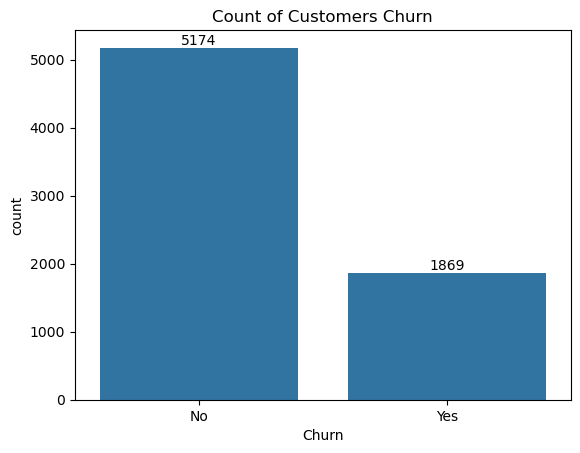

In [35]:
#To see the count of the no of churns
ax=sns.countplot(x ='Churn',data=df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers Churn")
plt.show()

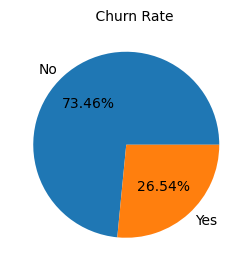

In [38]:
#if want to see the churn rate in %
plt.figure(figsize=(3,4))
gb = df.groupby('Churn').agg({'Churn':'count'})
plt.pie(gb['Churn'],labels = gb.index, autopct="%1.2f%%")
plt.title("    Churn Rate",fontsize=10)
plt.show()

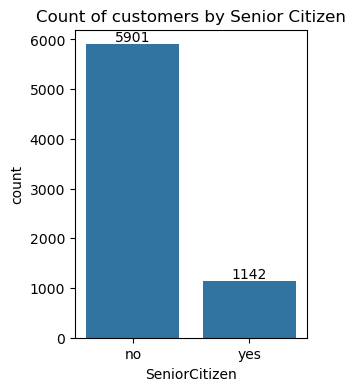

In [61]:
plt.figure(figsize=(3,4))
ax=sns.countplot(x ="SeniorCitizen", data=df)
ax.bar_label(ax.containers[0])
plt.title("Count of customers by Senior Citizen")
plt.show()

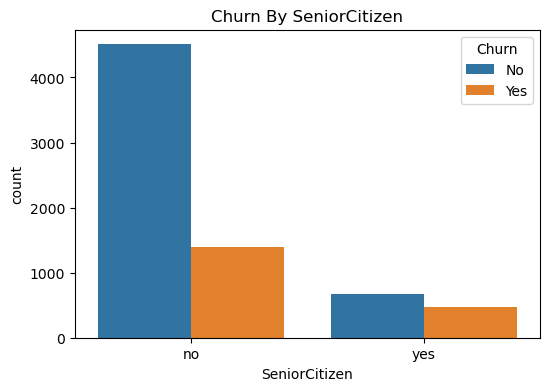

In [51]:
plt.figure(figsize=(6,4))
sns.countplot(x ="SeniorCitizen", data=df,hue='Churn')
plt.title("Churn By SeniorCitizen")
plt.show()

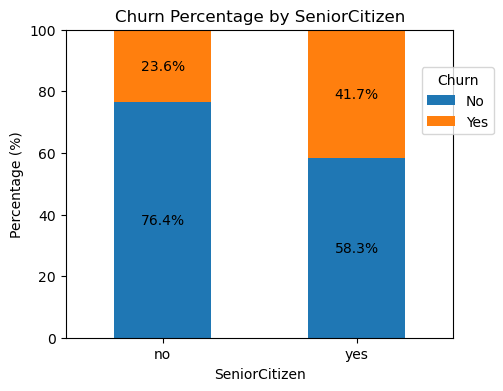

In [63]:
churn_pct = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

ax = churn_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(5, 4)
)

# Add percentage labels
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        label_type='center'
    )

plt.title("Churn Percentage by SeniorCitizen")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn",bbox_to_anchor=(0.9,0.9))#use bbox_to_anchor to adjust the position of legend
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

#Comparative a greater percentage of people in senior citizen category have churned

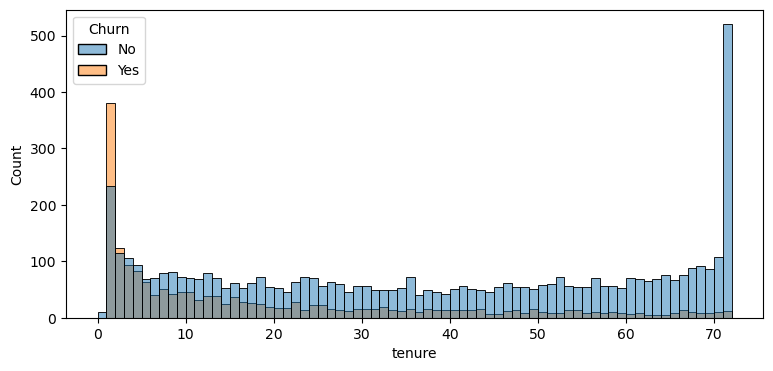

In [67]:
plt.figure(figsize=(9, 4))
sns.histplot(x="tenure",data=df,bins=72, hue="Churn")
plt.show()

#people who have used our services for a long time have stayed and people who have used our services for 1 or 2 month have churned.

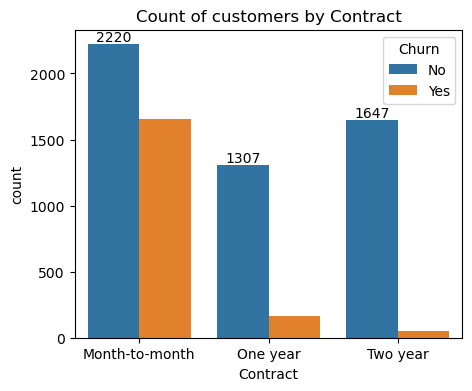

In [70]:
plt.figure(figsize=(5,4))
ax=sns.countplot(x ="Contract", data=df, hue="Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of customers by Contract")
plt.show()

#people who have month to month  contract are likely to churn then from those who have 1 or 2 yrs of contract.

In [71]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

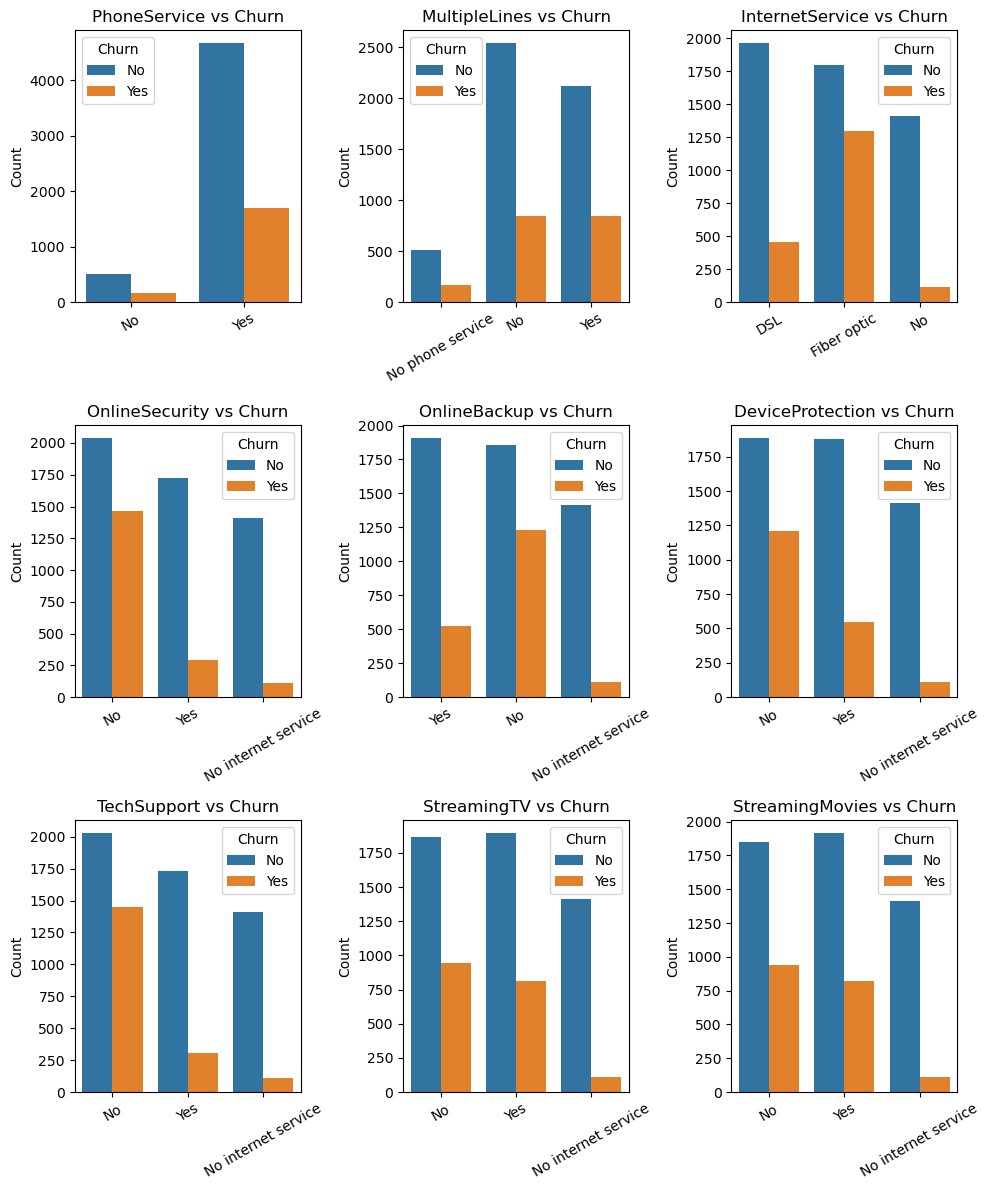

In [85]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(10,12))

for ax, col in zip(axes.flatten(), cols):
    sns.countplot(
        data=df,
        x=col,
        hue='Churn',
        ax=ax
    )
    
    ax.set_title(f'{col} vs Churn')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

<!-- 1.Customers without OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport show noticeably higher churn compared with customers who have these services.
2.Fiber optic internet users have the highest churn among the InternetService categories.
3.Customers with StreamingTV and StreamingMovies also show considerable churn, while customers with no internet service have very low churn.
4.Overall, lack of additional internet services and fiber-optic connectivity appear to be associated with higher customer churn. -->

#Customers without OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport show noticeably higher churn compared with customers who have these services.
#Fiber optic internet users have the highest churn among the InternetService categories.
#Customers with StreamingTV and StreamingMovies also show considerable churn, while customers with no internet service have very low churn.
#Overall, lack of additional internet services and fiber-optic connectivity appear to be associated with higher customer churn.

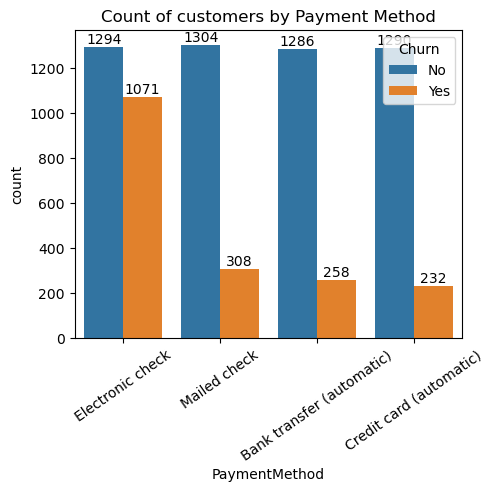

In [88]:
plt.figure(figsize=(5,4))
ax=sns.countplot(x ="PaymentMethod", data=df, hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Count of customers by Payment Method")
plt.xticks(rotation=35)
plt.show()

#customer is likely to churn when he is using the electronic check as payment method